In [2]:
import rich
import logging
import glob

import matplotlib.pyplot as plt
import time
import os
import awkward as ak
import numpy as np
import pandas as pd
from lgdo import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm
from pathlib import Path

%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)

In [15]:
## function

def build_geometry_data(detector_type,   # nome detector
                        channels_rawid,  # tutti i canali
                        psp_files,       # directory --> fissa
                        trigger_data,    # directory --> fissa
                        geds_data,       # directory --> fissa
                        coincident_data, # directory --> fissa
                        params,          # parametri DSP
                        classifier_params, # parametri classifier
                        outdir="Parquet data r000",
                        force=False):

    # --------------------------
    # PATH ROBUSTO
    # --------------------------
    outpath = Path(outdir) / f"data_{detector_type}_phy_ALL.parquet"
    outpath.parent.mkdir(parents=True, exist_ok=True)

    print(f"[INFO] Output path: {outpath.resolve()}")
    print(f"[INFO] Force mode: {force}")

    # --------------------------
    # CACHE LOGIC
    # --------------------------
    if force and outpath.exists():
        print(f"[INFO] Deleting old file: {outpath}")
        outpath.unlink()

    if outpath.exists() and not force:
        print(f"[INFO] Loading cached: {outpath}")
        return pd.read_parquet(outpath)

    # --------------------------
    # BUILD DATA
    # --------------------------
    dfs = []
    start = time.time()

    for channel in tqdm(channels_rawid[detector_type]):

        # CAL FILE DIPENDE DAL CANALE
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]

        df = load_data(
            files=psp_files,
            lh5_path=f"{channel}/dsp",
            cal_dict=cal_dict,
            params=params,
            return_selection_mask=False,
        ).copy()

        # --------------------------
        # FLAGS GLOBALI
        # --------------------------
        df["forced_trigger"] = ak.to_numpy(trigger_data["is_forced"])
        df["is_pulser"] = coincident_data["puls"]
        df["is_muon"] = coincident_data["muon_offline"]
        df["is_HPGe"] = coincident_data["geds"]

        df["is_discharge"] = geds_data.quality.is_not_bb_like.is_delayed_discharge

        df["is_below_500keV"] = (
            (df["cuspEmax_ctc_cal"] > 25) &
            (df["cuspEmax_ctc_cal"] < 500)
        )

        # --------------------------
        # CLASSIFIERS
        # --------------------------
        for param in classifier_params:
            df = classifier_fun(df, cal_dict, param)

        dfs.append(df)

    data = pd.concat(dfs, ignore_index=True)

    print(f"[INFO] Took {time.time() - start:.2f} s")

    # --------------------------
    # SAVE (atomic-like overwrite)
    # --------------------------
    tmp_path = outpath.with_suffix(".tmp.parquet")
    data.to_parquet(tmp_path, index=False)
    tmp_path.replace(outpath)

    print(f"[INFO] Saved: {outpath.resolve()}")

    return data


def classifier_fun(data, cal_dict, param):
    a_class = cal_dict[f"is_valid_{param}_classifier"]['parameters']['a']
    b_class = cal_dict[f"is_valid_{param}_classifier"]['parameters']['b']
    
    classifier = (data[f"{param}"] - a_class) / b_class

    data[f"classifier_{param}"] = classifier

    return data


def classifier_plot(data, param, bins = 250):
    # flags
    m_dis = ~data["is_discharge"]  # no scarica
    m_pulser = data["is_pulser"]   # si PULSER
    m_ft = data["forced_trigger"]  # si FORCED TRIGGER
    m_lowE = data["is_below_500keV"] # energie tra 25 e 500 keV
    m_coinc = data["is_HPGe"]&~data["is_muon"]
    
    # data
    classifier = data[f"classifier_{param}"]
    plt.figure(figsize = (8,6))
    plt.hist(classifier[m_dis], bins = bins, range = (-5, 15),  histtype = 'step', label = 'All')
    plt.hist(classifier[m_dis & m_pulser], bins = bins, range = (-5, 15),  histtype = 'step', label = 'is_pulser')
    plt.hist(classifier[m_dis & m_ft], bins = bins, range = (-5, 15),  histtype = 'step', label = 'is_forced_trigger')
    plt.hist(classifier[m_dis & ~m_ft & ~m_pulser & m_lowE], bins = bins, range = (-5, 15),  histtype = 'step', label = '~PL & ~FT & <500 keV')
    
    plt.vlines(-5, 0, 1e5, ls = '--', color = 'grey' )
    plt.vlines(5, 0, 1e5, ls = '--', color = 'grey', label = 'Classifier CUT' )
    plt.ylim(1, 1e5)
    plt.xlim(-6, 6)
    plt.legend(loc = 'upper right')
    plt.ylabel(f"Counts")
    plt.xlabel(f"Classifier {param}")
    plt.axvspan(-25, -5, color = 'grey', alpha=0.15)
    plt.axvspan(5,25, color = 'grey', alpha=0.15)
    #plt.title(f"{detector}")
    plt.yscale('log')
    plt.savefig(f"{param}_class.svg", dpi = 600)
    
    return

In [4]:
# path to data

data_path = "/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest"
config = Props.read_from(os.path.join(data_path, "config.json"), subst_pathvar=True)["setups"]["l200"]["paths"]
meta  = LegendMetadata(config["metadata"])
chmap = meta.channelmap(meta.dataprod.runinfo.p03.r000.phy.start_key)

In [5]:
# get files
# PRENDO I DATI DI FISICA E NON DI CALIBRAZIONE f"{config["tier_psp"]}/cal/p03/r000/*.lh5" ---> f"{config["tier_psp"]}/phy/p03/r000/*.lh5"
pet_files = sorted(glob.glob(f"{config["tier_pet"]}/phy/l200-p03-r000-phy-tier_pet.lh5"))
psp_files = sorted(glob.glob(f"{config["tier_psp"]}/phy/p03/r000/*.lh5")) #access exsiting DSP-processed data such as the energy for partitions
tcm_files = sorted(glob.glob(f"{config["tier_tcm"]}/phy/p03/r000/*.lh5"))  # --> solo per il pulse
raw_files = sorted(glob.glob(f"{config["tier_raw"]}/phy/p03/r000/*.lh5"))

In [6]:
geds_data = lh5.read_as("/evt/geds", pet_files, library="ak")
trigger_data = lh5.read_as("/evt/trigger", pet_files, library="ak")
coincident_data = lh5.read_as("/evt/coincident", pet_files, library="ak")

In [7]:
channel = f'ch{chmap.V02160A.daq.rawid}'
detector = "V02160A"
channel

'ch1104000'

In [8]:
# The cal_dict we can pull from a hit_results file generated by the dataflow

cal_file = f"{config["par_pht"]}/cal/p03/r000/l200-p03-r000-cal-20230311T235840Z-par_pht.json"
cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]



In [114]:
params = [ "bl_slope",
            "bl_slope_rms",
            "tail_rms",
            "cuspEmax",
            "cuspEmin",
            "is_low_cuspEmax",
            "is_low_cuspEmax_classifier",
            "is_valid_cuspEmax_classifier",
            "is_valid_cuspEmax",
            "is_valid_cuspEmin_classifier",
            "tp_trapTmax",
           "tp_trapTmin",
            "tp_0_est",
            "tp_10",
            "tp_50",
            "tp_90",
            "dt_eff ",
            "wf_min_win",
            "wf_max_win",
            "bl_mean",
            "tp_max_win",
            "tp_min_win",           
            "cuspEmax_ctc_cal",
            "is_valid_bl_slope",
            "is_valid_bl_slope_rms",
            "is_valid_tail_rms",
            "is_valid_cal",
            "is_valid_cuspEmin",
            "is_valid_trap_tpmax",
            "is_valid_trap_tpmin",
            "is_valid_t0",
            "is_valid_rt",
            "is_valid_dteff",
            "is_not_noise_burst"
    ]


In [115]:
# qui mi posso salvare i paramteri di DSP (che ho scelto e definito in config) per lo specfico canale e per tutti gli eventi registrati
start = time.time()
data = load_data(
        files = psp_files,   # da qui prenidmao i dati di dsp già processati 
        lh5_path = f"{channel}/dsp",  # prendo i risultati del dsp per il canale /detcetor specifico
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"],  # lo prendiamo da par_pht
        params=params,
        return_selection_mask=False,)

print(f"[INFO] Took {time.time() - start:.2f} s")


[INFO] Took 10.69 s


In [116]:
data

,bl_mean,bl_slope,bl_slope_rms,cuspEmax,cuspEmax_ctc,cuspEmax_ctc_cal,cuspEmin,dt_eff,is_low_cuspEmax,is_low_cuspEmax_classifier,...,tp_min,tp_min_win,tp_trapTmax,tp_trapTmin,trapTmax,trapTmin,wf_max,wf_max_win,wf_min,wf_min_win
0,15020.713867,0.016286,12.670416,0.320338,NaN,NaN,-4.234782,NaN,True,-0.661461,...,14080.0,60320.0,44032.0,64000.0,5.961780,-5.100899,15071.625,15084.0,14984.000,14965.0
1,15031.455078,0.017787,12.584935,4.296205,4.296067,0.035374,1.726118,-55.776174,True,0.848490,...,70528.0,42928.0,38784.0,79872.0,7.703803,-6.003372,15067.375,15095.0,14997.000,14983.0
2,15011.388672,-0.004746,12.783596,2.403704,2.403815,-0.257466,-1.394815,80.456719,True,0.129758,...,44672.0,46736.0,26112.0,47744.0,6.812665,-9.341866,15048.750,15054.0,14963.875,14924.0
3,14968.974609,0.019171,12.077505,1.586369,1.583160,-0.384468,-3.400333,-3517.598164,True,-0.180649,...,4480.0,59936.0,76672.0,88448.0,6.533368,-4.442032,15008.250,15046.0,14931.875,14912.0
4,15038.297852,0.004323,12.946972,4.474205,4.473058,0.062765,0.157404,-445.893938,True,0.916091,...,11008.0,63280.0,102272.0,41856.0,10.798269,-3.147958,15102.000,15101.0,14993.875,14983.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214041,15014.677734,-0.024594,11.275720,-0.864503,-0.861656,-0.762822,-4.378684,-5728.478773,True,-1.111439,...,109184.0,54560.0,89472.0,45056.0,2.711774,-7.709597,15046.000,15060.0,14968.125,14961.0
214042,15005.406250,-0.011811,12.153982,3.751267,3.749321,-0.049239,-0.897289,-902.339920,True,0.641534,...,93952.0,54032.0,34432.0,45440.0,4.524774,-7.436236,15044.750,15055.0,14959.250,14948.0
214043,15034.359375,-0.004945,11.519229,5.946424,5.940003,0.289785,-2.202198,-1877.894903,True,1.475209,...,32640.0,45264.0,55424.0,71808.0,5.754169,-9.222291,15078.375,15091.0,14993.375,14971.0
214044,15033.202148,-0.020248,11.674230,4.030265,4.021709,-0.007085,-0.057633,-3691.852868,True,0.747492,...,6912.0,51120.0,59008.0,81408.0,5.991364,-8.167828,15069.250,15085.0,14994.625,14981.0


In [117]:
# trigger
trigger_data = lh5.read_as("/evt/trigger", pet_files, library="ak")
data["forced_trigger"] = ak.to_numpy(trigger_data['is_forced'])

# pulsesr and coincidences 
coincident_data = lh5.read_as("/evt/coincident", pet_files, library="ak")
data["is_pulser"] = coincident_data['puls']  # no pulser events
data["is_muon"] = coincident_data['muon_offline']  # no muons
data["is_HPGe"] = coincident_data['geds']  # only events with an HPGe signal

# energy selection
mask_lowe = (data["cuspEmax_ctc_cal"] > 25) & (data["cuspEmax_ctc_cal"] < 500)
data["is_below_500keV"] = mask_lowe

### Discharge
geds_data = lh5.read_as("/evt/geds", pet_files, library="ak")
mask_discharge = geds_data.quality.is_not_bb_like.is_delayed_discharge
data["is_discharge"] = mask_discharge



In [118]:
params = ["bl_slope", 
          "bl_slope_rms",
         "tail_rms"]


In [119]:
for p in params:
     classifier_fun(data, cal_dict, p)

In [120]:
#classifier_plot(data, params[0])
#classifier_plot(data, params[1])
#classifier_plot(data, params[2])

## noise burst

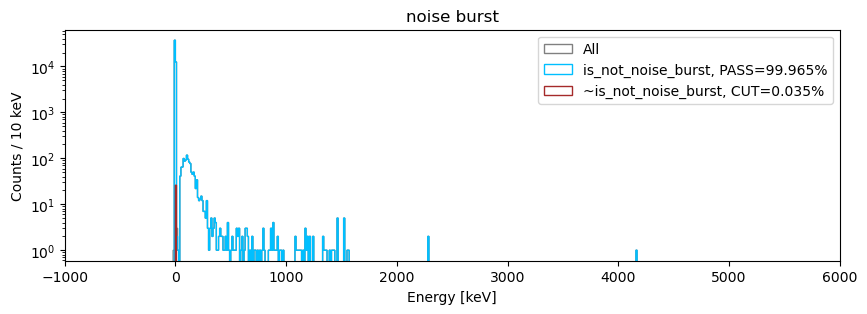

In [121]:
ene = data['cuspEmax_ctc_cal']
classifier_par = "bl_slope"
    
m_fix = data["is_HPGe"]&~data["is_muon"]
m_discharge = ~data["is_discharge"]

    
m_pulser = data["is_pulser"]
m_ft = data["forced_trigger"]
m_lowE = data["is_below_500keV"]
    

mtot = m_discharge & ~m_pulser & ~m_ft & m_fix
m_bl_slope = data[f"is_valid_bl_slope"]
m_bl_slope_rms = data[f"is_valid_bl_slope_rms"]
m_tail_rms = data[f"is_valid_tail_rms"]

m_qc = m_bl_slope & m_bl_slope_rms & m_tail_rms
m_noise_burst = data["is_not_noise_burst"]

    
CUT = len(ene[mtot & ~m_noise_burst]) * 100/ len(ene[mtot])
PASS = len(ene[mtot & m_noise_burst]) * 100/ len(ene[mtot])
    
emin = -1000
emax = 6000
bins = int((emax-emin)/10)
    
    
plt.figure(figsize = (10,3))
plt.hist(ene[mtot], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'gray',
             label = 'All'
            )
    
plt.hist(ene[mtot & m_qc & m_noise_burst], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'deepskyblue',
             label = f'is_not_noise_burst, PASS={PASS:.3f}%'
            )
   
plt.hist(ene[mtot & m_qc & ~m_noise_burst], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'brown',
             label = f'~is_not_noise_burst, CUT={CUT:.3f}%'
        )
    
plt.legend(loc = 'upper right')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts / 10 keV')
plt.title(f'noise burst')
plt.xlim(emin, emax)
plt.yscale('log')


#  Et trap min

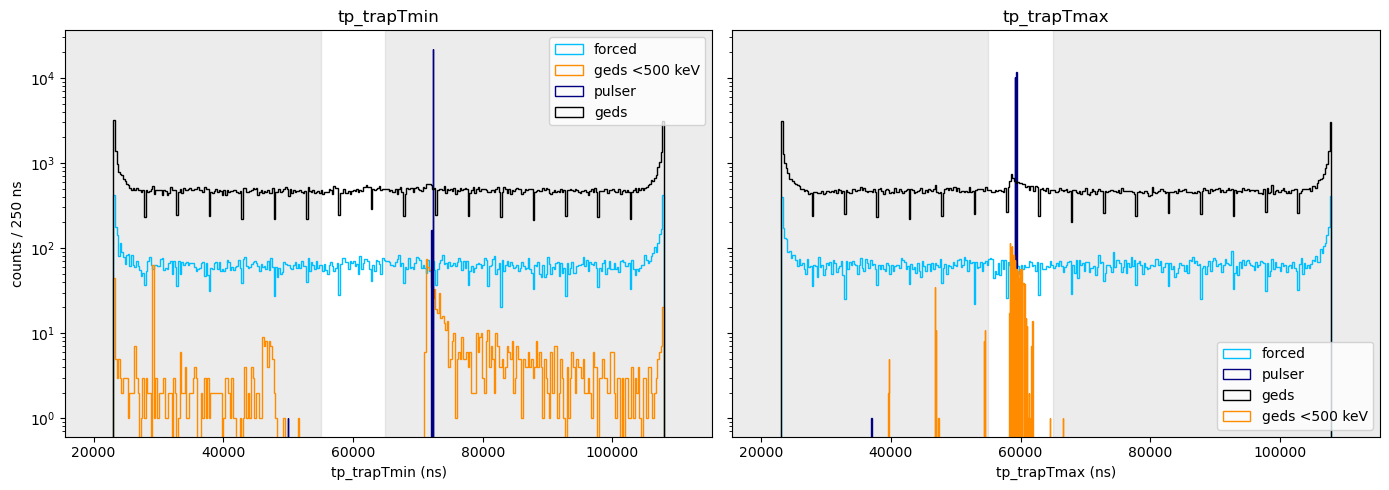

In [122]:
tlow = 55000
thigh = 65000

tp_trapTmax = data["tp_trapTmax"]
tp_trapTmin = data["tp_trapTmin"]

bins = 340

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# -----------------
# tp_trapTmin
# -----------------
cnts, bc, _ = ax[0].hist(
    tp_trapTmin[m_ft],
    bins=bins,
    color='deepskyblue',
    histtype='step',
    label='forced'
)

ax[0].hist(
    tp_trapTmin[~m_ft & ~m_pulser & data['is_below_500keV']],
    bins=bins,
    color='darkorange',
    histtype='step',
    label='geds <500 keV'
)

ax[0].hist(
    tp_trapTmin[m_pulser],
    bins=bins,
    color='navy',
    histtype='step',
    label='pulser'
)

ax[0].hist(
    tp_trapTmin[~m_ft & ~m_pulser],
    bins=bins,
    color='black',
    histtype='step',
    label='geds'
)

ax[0].axvspan(tp_trapTmin.min()-7500, tlow, color='grey', alpha=0.15)
ax[0].axvspan(thigh, tp_trapTmin.max()+7500, color='grey', alpha=0.15)
ax[0].set_xlim(tp_trapTmin.min()-7500, tp_trapTmin.max()+7500)
ax[0].set_xlabel("tp_trapTmin (ns)")
ax[0].set_ylabel(f"counts / {bc[1]-bc[0]:.0f} ns")
ax[0].set_yscale('log')
ax[0].set_title("tp_trapTmin")
ax[0].legend()

# -----------------
# tp_trapTmax
# -----------------
cnts2, bc2, _ = ax[1].hist(
    tp_trapTmax[m_ft],
    bins=bins,
    color='deepskyblue',
    histtype='step',
    label='forced'
)

ax[1].hist(
    tp_trapTmax[m_pulser],
    bins=bins,
    color='navy',
    histtype='step',
    label='pulser'
)

ax[1].hist(
    tp_trapTmax[~m_ft & ~m_pulser],
    bins=bins,
    color='black',
    histtype='step',
    label='geds'
)
ax[1].hist(
    tp_trapTmax[~m_ft & ~m_pulser & data['is_below_500keV']],
    bins=bins,
    color='darkorange',
    histtype='step',
    label='geds <500 keV'
)

ax[1].axvspan(tp_trapTmax.min()-7500, tlow, color='grey', alpha=0.15)
ax[1].axvspan(thigh, tp_trapTmax.max()+7500, color='grey', alpha=0.15)
ax[1].set_xlim(tp_trapTmax.min()-7500, tp_trapTmax.max()+7500)
ax[1].set_xlabel("tp_trapTmax (ns)")
ax[1].set_yscale('log')
ax[1].set_title("tp_trapTmax")
ax[1].legend()

plt.tight_layout()
plt.show()

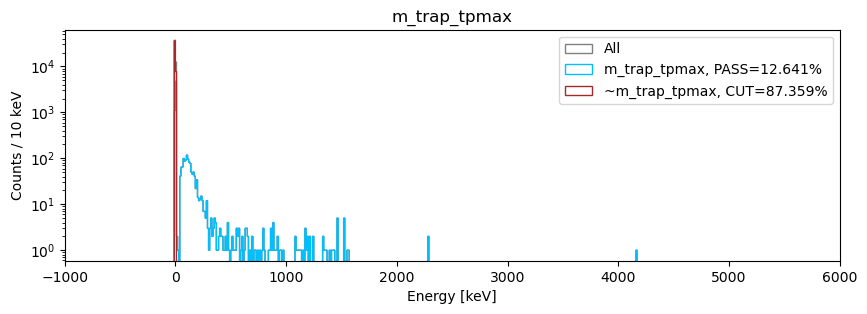

In [128]:
ene = data['cuspEmax_ctc_cal']
classifier_par = "bl_slope"
    
m_fix = data["is_HPGe"]&~data["is_muon"]
m_discharge = ~data["is_discharge"]

    
m_pulser = data["is_pulser"]
m_ft = data["forced_trigger"]
m_lowE = data["is_below_500keV"]
m_noise_burst = data["is_not_noise_burst"]

m_trap_tpmax = data["is_valid_trap_tpmax"]

m_bl_slope = data[f"is_valid_bl_slope"]
m_bl_slope_rms = data[f"is_valid_bl_slope_rms"]
m_tail_rms = data[f"is_valid_tail_rms"]

m_qc = m_bl_slope & m_bl_slope_rms & m_tail_rms & m_noise_burst

mtot = m_discharge & ~m_pulser & ~m_ft & m_fix & m_qc
    
CUT = len(ene[mtot & ~m_trap_tpmax]) * 100/ len(ene[mtot])
PASS = len(ene[mtot & m_trap_tpmax]) * 100/ len(ene[mtot])
    
emin = -1000
emax = 6000
bins = int((emax-emin)/10)
    
    
plt.figure(figsize = (10,3))
plt.hist(ene[mtot], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'gray',
             label = 'All'
            )
    
plt.hist(ene[mtot & m_qc & m_trap_tpmax], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'deepskyblue',
             label = f'm_trap_tpmax, PASS={PASS:.3f}%'
            )
   
plt.hist(ene[mtot & m_qc & ~m_trap_tpmax], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'brown',
             label = f'~m_trap_tpmax, CUT={CUT:.3f}%'
        )
    
plt.legend(loc = 'upper right')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts / 10 keV')
plt.title(f'm_trap_tpmax')
plt.xlim(emin, emax)
plt.yscale('log')


# Pulse start time

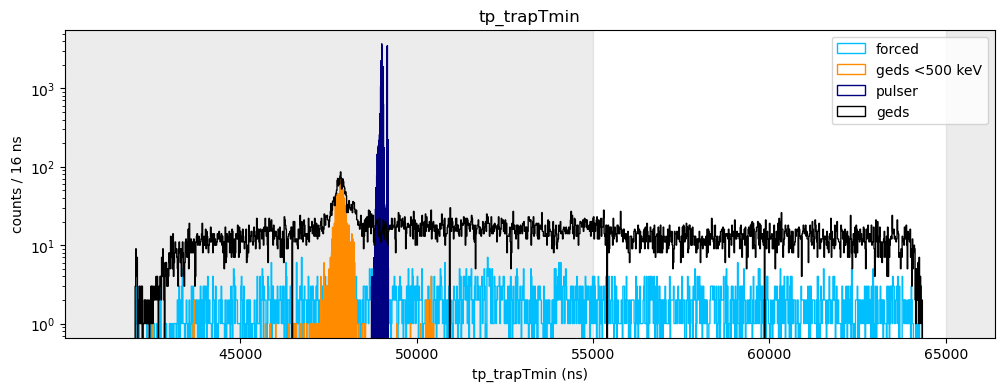

In [153]:
tpmax_low = 4600
tpmax_high = 5000

data_puls = data[m_trap_tpmax]
t0_est = data['tp_0_est']

bins = 1400

plt.figure(figsize = (12,4))
# -----------------
# tp_trapTmin
# -----------------
cnts, bc, _ = plt.hist(
    t0_est[m_ft & m_trap_tpmax],
    bins=bins,
    color='deepskyblue',
    histtype='step',
    label='forced'
)


plt.hist(
    t0_est[~m_ft & ~m_pulser & m_trap_tpmax & data['is_below_500keV']],
    bins=bins,
    color='darkorange',
    histtype='step',
    label='geds <500 keV'
)

plt.hist(
   t0_est[m_pulser & m_trap_tpmax],
    bins=bins,
    color='navy',
    histtype='step',
    label='pulser'
)

plt.hist(
    t0_est[~m_ft & ~m_pulser & m_trap_tpmax],
    bins=bins,
    color='black',
    histtype='step',
    label='geds'
)

plt.axvspan(t0_est.min()-2000, tlow, color='grey', alpha=0.15)
plt.axvspan(thigh, t0_est.max()+2000, color='grey', alpha=0.15)
plt.xlim(t0_est.min()-2000, t0_est.max()+2000)
plt.xlabel("tp_trapTmin (ns)")
plt.ylabel(f"counts / {bc[1]-bc[0]:.0f} ns")
plt.yscale('log')
plt.title("tp_trapTmin")
plt.legend()

# pulse rise time

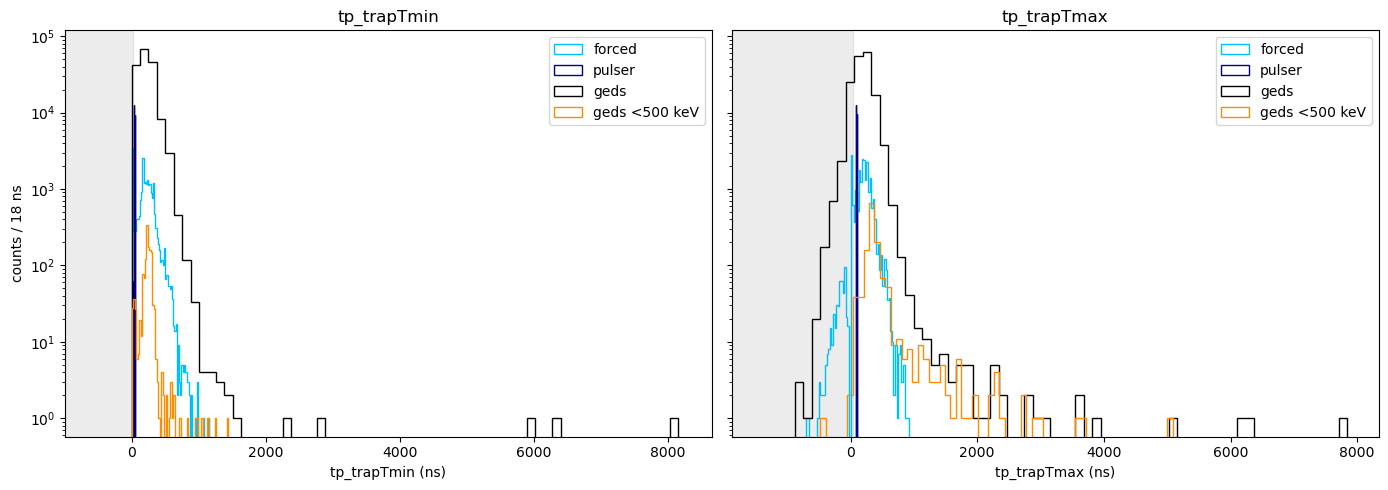

In [165]:
t_10_50 = data['tp_50'] - data['tp_10'] 
t_10_90 = data['tp_90'] - data['tp_10'] 



tlow = 16
thigh = 31


bins = 65

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# -----------------
# tp_trapTmin
# -----------------
cnts, bc, _ = ax[0].hist(
    t_10_50[m_ft],
    bins=bins,
    color='deepskyblue',
    histtype='step',
    label='forced'
)

ax[0].hist(
    t_10_50[m_pulser],
    bins=bins,
    color='navy',
    histtype='step',
    label='pulser'
)

ax[0].hist(
    t_10_50[~m_ft & ~m_pulser],
    bins=bins,
    color='black',
    histtype='step',
    label='geds'
)

ax[0].hist(
    t_10_50[~m_ft & ~m_pulser & data['is_below_500keV']],
    bins=bins,
    color='darkorange',
    histtype='step',
    label='geds <500 keV'
)

ax[0].axvspan(t_10_50.min()-1000, tlow, color='grey', alpha=0.15)
ax[0].set_xlim(t_10_50.min()-1000, t_10_50.max()+500)
ax[0].set_xlabel("tp_trapTmin (ns)")
ax[0].set_ylabel(f"counts / {bc[1]-bc[0]:.0f} ns")
ax[0].set_yscale('log')
ax[0].set_title("tp_trapTmin")
ax[0].legend()

# -----------------
# tp_trapTmax
# -----------------
cnts2, bc2, _ = ax[1].hist(
    t_10_90[m_ft],
    bins=bins,
    color='deepskyblue',
    histtype='step',
    label='forced'
)

ax[1].hist(
    t_10_90[m_pulser],
    bins=bins,
    color='navy',
    histtype='step',
    label='pulser'
)

ax[1].hist(
    t_10_90[~m_ft & ~m_pulser],
    bins=bins,
    color='black',
    histtype='step',
    label='geds'
)
ax[1].hist(
    t_10_90[~m_ft & ~m_pulser & data['is_below_500keV']],
    bins=bins,
    color='darkorange',
    histtype='step',
    label='geds <500 keV'
)

ax[1].axvspan(t_10_90.min()-1000, thigh, color='grey', alpha=0.15)
ax[1].set_xlim(t_10_90.min()-1000, t_10_90.max()+500)
ax[1].set_xlabel("tp_trapTmax (ns)")
ax[1].set_yscale('log')
ax[1].set_title("tp_trapTmax")
ax[1].legend()

plt.tight_layout()
plt.show()

In [177]:
'''
t_10_50 = data['tp_50'] - data['tp_10']
t_10_90 = data['tp_90'] - data['tp_10']

mask = np.isfinite(t_10_50) & np.isfinite(t_10_90)

m_is_empty

y = t_10_50[mask & ~m_pulser & ~m_ft]
x = t_10_90[mask & ~m_pulser & ~m_ft]

bins = 500

fig = plt.figure(figsize=(8, 8))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=(4, 1),
    height_ratios=(1, 4),
    hspace=0.05,
    wspace=0.05
)

ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# --- Colormap con zeri in bianco ---
cmap = plt.cm.viridis.copy()
cmap.set_under('white')

# Istogramma 2D
h = ax_main.hist2d(
    x,
    y,
    bins=bins,
    cmap=cmap,
    vmin=1   # <-- fondamentale: 0 eventi = "under"
)

# Colorbar
cbar = fig.colorbar(h[3], ax=ax_main)
cbar.set_label('Counts')

# Istogrammi marginali
ax_top.hist(x, bins=bins)
ax_top.hist(x, bins=bins)
ax_right.hist(y, bins=bins, orientation='horizontal')

# Etichette
ax_main.set_xlabel('t_10_50')
ax_main.set_ylabel('t_10_90')
ax_main.set_xlim(-50, 800)
ax_main.set_ylim(-50, 800)

# Nasconde etichette duplicate
ax_top.tick_params(axis='x', labelbottom=False)
ax_right.tick_params(axis='y', labelleft=False)

plt.show()'''

'\nt_10_50 = data[\'tp_50\'] - data[\'tp_10\']\nt_10_90 = data[\'tp_90\'] - data[\'tp_10\']\n\nmask = np.isfinite(t_10_50) & np.isfinite(t_10_90)\n\nm_is_empty\n\ny = t_10_50[mask & ~m_pulser & ~m_ft]\nx = t_10_90[mask & ~m_pulser & ~m_ft]\n\nbins = 500\n\nfig = plt.figure(figsize=(8, 8))\n\ngs = fig.add_gridspec(\n    2, 2,\n    width_ratios=(4, 1),\n    height_ratios=(1, 4),\n    hspace=0.05,\n    wspace=0.05\n)\n\nax_main = fig.add_subplot(gs[1, 0])\nax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)\nax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)\n\n# --- Colormap con zeri in bianco ---\ncmap = plt.cm.viridis.copy()\ncmap.set_under(\'white\')\n\n# Istogramma 2D\nh = ax_main.hist2d(\n    x,\n    y,\n    bins=bins,\n    cmap=cmap,\n    vmin=1   # <-- fondamentale: 0 eventi = "under"\n)\n\n# Colorbar\ncbar = fig.colorbar(h[3], ax=ax_main)\ncbar.set_label(\'Counts\')\n\n# Istogrammi marginali\nax_top.hist(x, bins=bins)\nax_top.hist(x, bins=bins)\nax_right.hist(y, bins=bins, orien